In [377]:
import numpy as np
import matplotlib.pyplot as plt

### Inputs: p1, p2, p3

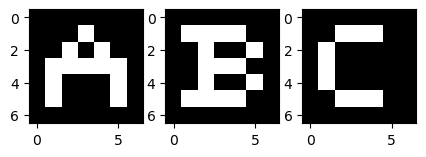

In [229]:
p1 = np.array([[-1,-1,-1,-1,-1,-1,-1],
              [-1,-1,-1,1,-1,-1,-1],
              [-1,-1,1,-1,1,-1,-1],
              [-1,1,1,1,1,1,-1],
              [-1,1,-1,-1,-1,1,-1],
              [-1,1,-1,-1,-1,1,-1],
              [-1,-1,-1,-1,-1,-1,-1],]
            )


p2 = np.array([[-1,-1,-1,-1,-1,-1,-1],
              [-1,1,1,1,1,-1,-1],
              [-1,-1,1,-1,-1,1,-1],
              [-1,-1,1,1,1,-1,-1],
              [-1,-1,1,-1,-1,1,-1],
              [-1,1,1,1,1,-1,-1],
              [-1,-1,-1,-1,-1,-1,-1]]
            )

p3 = np.array([[-1,-1,-1,-1,-1,-1,-1],
              [-1,-1,1,1,1,-1,-1],
              [-1,1,-1,-1,-1,-1,-1],
              [-1,1,-1,-1,-1,-1,-1],
              [-1,1,-1,-1,-1,-1,-1],
              [-1,-1,1,1,1,-1,-1],
              [-1,-1,-1,-1,-1,-1,-1]]
            )
plt.figure(figsize=(5,4))
plt.subplot(1,3,1)
plt.imshow(a,cmap='gray')

plt.subplot(1,3,2)
plt.imshow(b,cmap='gray')

plt.subplot(1,3,3)
plt.imshow(c,cmap='gray')

plt.show()

### Target: t1, t2, t3

In [231]:
t1 = np.array([1,0,0])
t2 = np.array([0,1,0])
t3 = np.array([0,0,1])

t = np.array([t1,t2,t3]).T
print(t.shape)
t

(3, 3)


array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])

### Flatten each input p and put as column in matrix P

In [379]:
p1 = np.ravel(p1)
p2 = np.ravel(p2)
p3 = np.ravel(p3)
p = np.array([p1,p2,p3]).T
print(p.shape)
#p


(49, 3)


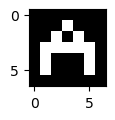

In [234]:
# Check if a column in matrix p is an image or letter
plt.figure(figsize=(1,1))
plt.imshow(p[:,0].reshape(7,7), cmap='gray')
plt.show()

In [235]:
p1.shape

(49,)

### Calculate: W = T.P^T

In [237]:
w_hebb = np.matmul(t,p.T)
print(w_hebb.shape)
w_hebb

(3, 49)


array([[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1,
         1, -1,  1, -1, -1, -1,  1,  1,  1,  1,  1, -1, -1,  1, -1, -1,
        -1,  1, -1, -1,  1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1,
        -1],
       [-1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1, -1, -1, -1, -1,
         1, -1, -1,  1, -1, -1, -1,  1,  1,  1, -1, -1, -1, -1,  1, -1,
        -1,  1, -1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1],
       [-1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1, -1, -1, -1,  1,
        -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1,  1, -1, -1,
        -1, -1, -1, -1, -1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1]])

### Now try to predict targets using this 'w_hebb'

In [239]:
t1_hebb = np.matmul(w_hebb,p1.reshape(49,1))
print(t1_hebb.shape)
t1_hebb

(3, 1)


array([[49],
       [23],
       [19]])

In [240]:
t2_hebb = np.matmul(w_hebb,p2.reshape(49,1))
print(t2_hebb.shape)
t2_hebb

(3, 1)


array([[23],
       [49],
       [25]])

In [241]:
t3_hebb = np.matmul(w_hebb,p3.reshape(49,1))
print(t3_hebb.shape)
t3_hebb

(3, 1)


array([[19],
       [25],
       [49]])

### Now calculate pseudoinverse of input matrix p

In [243]:
# p+ = (p^T.p).p^T

pT_p = np.matmul(p.T, p)
print(pT_p.shape)

pT_p_inv = np.linalg.inv(pT_p)

pinv = np.matmul(pT_p_inv,p.T) # check with np.linalg.pinv(p)
print(pinv.shape)
#pinv

(3, 3)
(3, 49)


### Use the pseudoinverse of p to calculate w

In [245]:
w_inv = np.matmul(t,pinv)
print(w_inv.shape)
#w_inv

(3, 49)


### Now try to predict target t using the pseudoinverse w

In [381]:
t1_inv = np.matmul(w_inv,p1.reshape(49,1))
print(t1_inv.shape)
t1_inv.round()

(3, 1)


array([[ 1.],
       [-0.],
       [ 0.]])

In [383]:
t2_inv = np.matmul(w_inv,p2.reshape(49,1))
print(t2_inv.shape)
t2_inv.round()

(3, 1)


array([[0.],
       [1.],
       [0.]])

In [385]:
t3_inv = np.matmul(w_inv,p3.reshape(49,1))
print(t3_inv.shape)
t3_inv.round()

(3, 1)


array([[ 0.],
       [-0.],
       [ 1.]])

### Now delete lower half of each image and see if w_inv can predict

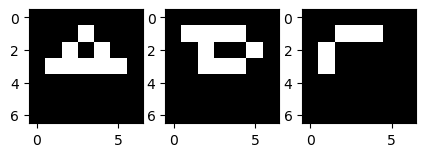

In [387]:
p1_half = p1.copy().reshape(7,7)
p1_half[4:,:]=-1

p2_half = p2.copy().reshape(7,7)
p2_half[4:,:]=-1

p3_half = p3.copy().reshape(7,7)
p3_half[4:,:]=-1


plt.figure(figsize=(5,4))
plt.subplot(1,3,1)
plt.imshow(p1_half,cmap='gray')

plt.subplot(1,3,2)
plt.imshow(p2_half,cmap='gray')

plt.subplot(1,3,3)
plt.imshow(p3_half,cmap='gray')

plt.show()



In [389]:
t1_half_inv = np.matmul(w_inv,p1_half.reshape(49,1))
print(t1_half_inv.shape)
t1_half_inv.round()

(3, 1)


array([[1.],
       [0.],
       [0.]])

In [253]:
t2_half_inv = np.matmul(w_inv,p2_half.reshape(49,1))
print(t2_half_inv.shape)
t2_half_inv.round()

(3, 1)


array([[0.],
       [1.],
       [0.]])

In [254]:
t3_half_inv = np.matmul(w_inv,p3_half.reshape(49,1))
print(t3_half_inv.shape)
t3_half_inv.round()

(3, 1)


array([[ 0.],
       [-0.],
       [ 1.]])

### Now add gaussian noise and see if w_inv can still predict !!!

In [451]:
# Set the threshold for noise
threshold = 2 # try values: (low noise)0.01, 0.1, 0.2, 0.4, 0.8, 0.9, 1.0, 1.5, 2.0 (high noise)
noise = threshold *  np.random.randn(7,7)

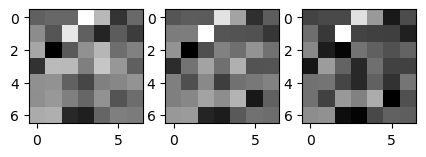

In [453]:
p1_gauss = p1.copy().reshape(7,7) + noise
p2_gauss = p2.copy().reshape(7,7) + noise
p3_gauss = p3.copy().reshape(7,7) + noise


plt.figure(figsize=(5,4))
plt.subplot(1,3,1)
plt.imshow(p1_gauss,cmap='gray')

plt.subplot(1,3,2)
plt.imshow(p2_gauss,cmap='gray')

plt.subplot(1,3,3)
plt.imshow(p3_gauss,cmap='gray')

plt.show()



### Now try to predict with w_inv

In [456]:
t1_gauss_inv = np.matmul(w_inv,p1_gauss.reshape(49,1))
print(t1_gauss_inv.shape)
t1_gauss_inv.round()

(3, 1)


array([[ 1.],
       [ 0.],
       [-0.]])

In [458]:
t2_gauss_inv = np.matmul(w_inv,p2_gauss.reshape(49,1))
print(t2_gauss_inv.shape)
t2_gauss_inv.round()

(3, 1)


array([[-0.],
       [ 1.],
       [-0.]])

In [460]:
t3_gauss_inv = np.matmul(w_inv,p3_gauss.reshape(49,1))
print(t3_gauss_inv.shape)
t3_gauss_inv.round()

(3, 1)


array([[-0.],
       [ 0.],
       [ 1.]])

:)